Generated with Claude 4.5 Sonnet
DCR Analysis 

In [154]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time
from astropy import units as u
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import lsst.daf.butler as dafButler
from lsst.rsp import get_tap_service, retrieve_query
from scipy.ndimage import rotate

# For API access
import requests
from io import BytesIO
from astropy.io import fits

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

#if using API
# from APIaccess import get_tap_service

In [289]:
# Configuration
TARGET_RA = 53.12652887  # degrees - CHANGE THIS
TARGET_DEC = -28.31641564  # degrees - CHANGE THIS

# TARGET_RA = 53.0466785 # degrees - CHANGE THIS
# TARGET_DEC = -28.0638600# degrees - CHANGE THIS

# TARGET_RA, TARGET_DEC = 53.0711974, -27.9880237
# TARGET_RA, TARGET_DEC = 53.1823591, -28.2982115 # 53.1461228, -27.9259735

SEARCH_RADIUS = 1.0  # arcseconds


# BUTLER_REPO = 's3://rubin-dp01'  # DP1 repository
# BUTLER_COLLECTION = '2.2i/runs/DP0.1'

# LSST location for altitude/azimuth calculations
LSST_LOCATION = EarthLocation(lat=-30.244639*u.deg, 
                               lon=-70.749417*u.deg, 
                               height=2663*u.m)

In [290]:
# Initialize Butler (for Rubin Science Platform)
butler = dafButler.Butler("dp1", collections="LSSTComCam/DP1")

In [291]:
# Query for object and source detections
def query_object_and_sources(ra, dec, radius_arcsec=1.0):
    """
    Query the Object catalog and DiaSource/Source catalogs for detections
    """
    service = get_tap_service("tap")
    
    # Query for the object
    object_query = f"""SELECT objectId, parentObjectID, coord_ra, coord_dec, 
           g_cModelMag, r_cModelMag, i_cModelMag,
           g_cModelMagErr, r_cModelMagErr, i_cModelMagErr
    FROM dp1.Object
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
                   CIRCLE('ICRS', {ra}, {dec}, {radius_arcsec/3600.0})) = 1
    """
    
    job = service.submit_job(object_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    object_result = job.fetch_result().to_table().to_pandas()
    
    # object_result = service.search(object_query).to_table().to_pandas()
    print(len(object_result))

    if len(object_result) > 1:
        print('multiple objects found')
        return None, None
        
    if len(object_result) == 0:
        print("No object found at these coordinates!")
        return None, None
    
    object_id = object_result['parentObjectID'].values[0]
    true_ra = object_result['coord_ra'].values[0]
    true_dec = object_result['coord_dec'].values[0]
    
    print(f"Found object {object_id} at RA={true_ra:.6f}, Dec={true_dec:.6f}")
    
    # Query for all source detections
    source_query_deprecated = f"""
    SELECT src.diaSourceId, src.diaObjectId, 
           src.coord_ra, src.coord_dec,
           src.ra, src.decl,
           src.x, src.y,
           src.psFlux, src.psFluxErr,
           src.ixx, src.iyy, src.ixy,
           src.visit, src.detector,
           src.band, src.ccdVisitId,
           vis.expMidptMJD, vis.zenithDistance, 
           vis.parallacticAngle, vis.airmass,
           vis.seeing, vis.skyBg,
           vis.expTime
    FROM dp1.diaSource AS src
    JOIN dp1.visitInfo AS vis ON src.visit = vis.visit
    WHERE src.diaObjectId = {object_id}
    ORDER BY vis.zenithDistance
    """

    source_query = f"""
    SELECT src.coord_ra, src.coord_dec,
           src.ra, src.dec,
           src.x, src.y,
           src.psfFlux, src.psfFluxErr,
           src.ixx, src.iyy, src.ixy,
           src.visit, src.detector,
           src.band,
           vis.expMidptMJD, vis.zenithDistance, vis.airmass,
           vis.expTime, vis.skyRotation
    FROM dp1.Source AS src
    JOIN dp1.Visit AS vis ON src.visit = vis.visit
    WHERE CONTAINS(POINT('ICRS', src.coord_ra, src.coord_dec),
                   CIRCLE('ICRS', {ra}, {dec}, {radius_arcsec/3600.0})) = 1
    ORDER BY vis.zenithDistance
    """

    job = service.submit_job(source_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    sources = job.fetch_result().to_table().to_pandas()

    # sources = service.search(source_query).to_table().to_pandas()
    
    print(f"Found {len(sources)} source detections")
    
    return object_result, sources

# Execute query
object_info, sources = query_object_and_sources(TARGET_RA, TARGET_DEC, SEARCH_RADIUS)

Job phase is COMPLETED
1
Found object 609789561081430836 at RA=53.126528, Dec=-28.316416
Job phase is COMPLETED
Found 690 source detections


In [292]:
# Display source information
if sources is not None:
    print("\n=== Object Information ===")
    display(object_info)
    print("\n=== Source Detections (first 20) ===")
    display(sources[['band', 'visit', 'detector', 'zenithDistance', 
                      'airmass', 'coord_ra', 'coord_dec']].head(20))


=== Object Information ===


,objectId,parentObjectID,coord_ra,coord_dec,g_cModelMag,r_cModelMag,i_cModelMag,g_cModelMagErr,r_cModelMagErr,i_cModelMagErr
0,609789561081442089,609789561081430836,53.126528,-28.316416,18.557199,18.664101,18.744801,0.000213,0.000233,0.000355



=== Source Detections (first 20) ===


,band,visit,detector,zenithDistance,airmass,coord_ra,coord_dec
0,u,2024113000176,8,8.730097,1.011696,53.126532,-28.316420
1,u,2024113000175,8,9.047625,1.012574,53.126536,-28.316418
2,u,2024113000173,4,9.089573,1.012690,53.126524,-28.316417
3,r,2024120600099,5,9.198567,1.013000,53.126528,-28.316416
4,r,2024120600098,5,9.344685,1.013420,53.126530,-28.316415
5,u,2024113000172,5,9.347993,1.013431,53.126531,-28.316415
6,r,2024120600097,7,9.629577,1.014261,53.126529,-28.316413
7,g,2024113000171,4,9.667564,1.014377,53.126525,-28.316411
8,r,2024120600096,4,9.702567,1.014480,53.126527,-28.316411
9,r,2024120300115,3,9.833231,1.014885,53.126526,-28.316416


In [293]:
# Calculate Alt/Az and Parallactic Angle for each detection
def calculate_altaz_and_parallactic(sources, object_info):
    """
    Calculate altitude, azimuth, and parallactic angle for each source detection
    
    Parallactic angle is the position angle of the vertical circle through the object,
    measured from North through East. It describes the rotation of the field relative
    to the celestial coordinate system.
    """
    true_coord = SkyCoord(ra=object_info['coord_ra'].values[0]*u.deg,
                          dec=object_info['coord_dec'].values[0]*u.deg)
    
    alt_list = []
    az_list = []
    parallactic_list = []
    
    for idx, row in sources.iterrows():
        obs_time = Time(row['expMidptMJD'], format='mjd')
        altaz_frame = AltAz(obstime=obs_time, location=LSST_LOCATION)
        altaz = true_coord.transform_to(altaz_frame)
        
        # Calculate parallactic angle
        # Formula: tan(q) = sin(H) / (tan(lat)*cos(dec) - sin(dec)*cos(H))
        # where H is the hour angle, lat is the observatory latitude
        
        # Get hour angle
        lst = obs_time.sidereal_time('apparent', longitude=LSST_LOCATION.lon)
        hour_angle = lst - true_coord.ra
        
        lat = LSST_LOCATION.lat
        dec = true_coord.dec
        
        # Calculate parallactic angle
        numerator = np.sin(hour_angle)
        denominator = (np.tan(lat) * np.cos(dec) - 
                      np.sin(dec) * np.cos(hour_angle))
        
        parallactic_angle = np.arctan2(numerator, denominator)
        
        alt_list.append(altaz.alt.deg)
        az_list.append(altaz.az.deg)
        parallactic_list.append(parallactic_angle.to(u.deg).value)
    
    sources['altitude'] = alt_list
    sources['azimuth'] = az_list
    sources['parallacticAngle'] = parallactic_list
    
    return sources

sources = calculate_altaz_and_parallactic(sources, object_info)

print("\n=== Calculated Observing Conditions ===")
display(sources[['visit', 'band', 'zenithDistance', 'altitude', 'azimuth', 
                  'parallacticAngle', 'airmass']].head(10))


=== Calculated Observing Conditions ===


,visit,band,zenithDistance,altitude,azimuth,parallacticAngle,airmass
0,2024113000176,u,8.730097,81.575784,78.506895,-105.840956,1.011696
1,2024113000175,u,9.047625,81.392920,78.860032,-105.589095,1.012574
2,2024113000173,u,9.089573,81.029388,79.524675,-105.127154,1.012690
3,2024120600099,r,9.198567,80.927982,79.704058,-105.006833,1.013000
4,2024120600098,r,9.344685,80.798480,79.925438,-104.858154,1.013420
5,2024113000172,u,9.347993,80.846756,79.841357,-104.912901,1.013431
6,2024120600097,r,9.629577,80.668135,80.142972,-104.713965,1.014261
7,2024113000171,g,9.667564,80.490642,80.428978,-104.525957,1.014377
8,2024120600096,r,9.702567,80.540871,80.350465,-104.578234,1.014480
9,2024120300115,r,9.833231,79.952110,278.747985,103.629013,1.014885


In [294]:
# Select observations at different zenith angles
def select_observations_for_analysis(sources, n_samples=6, bands=None, 
                                     ensure_extremes=True):
    """
    Select observations including min, max, and intermediate zenith angles
    
    Parameters:
    -----------
    sources : DataFrame
        Source detections with observing conditions
    n_samples : int
        Total number of observations to select
    bands : list or None
        List of bands to include (e.g., ['g', 'r', 'i']). If None, uses all bands
    ensure_extremes : bool
        If True, ensures min and max zenith angles are included
    
    Returns:
    --------
    DataFrame
        Selected observations sorted by zenith distance
    """
    # Filter by band if specified
    if bands is not None:
        if isinstance(bands, str):
            bands = [bands]
        filtered_sources = sources[sources['band'].isin(bands)].copy()
        print(f"Filtered to {len(filtered_sources)} observations in bands {bands}")
    else:
        filtered_sources = sources.copy()
    
    if len(filtered_sources) == 0:
        print("No sources found matching the filter criteria!")
        return pd.DataFrame()
    
    # Show band distribution
    print("\nBand distribution:")
    print(filtered_sources['band'].value_counts())
    
    if ensure_extremes and len(filtered_sources) >= 2:
        # Ensure we have the extremes
        min_zenith_idx = filtered_sources['zenithDistance'].idxmin()
        max_zenith_idx = filtered_sources['zenithDistance'].idxmax()
        
        # Select intermediate observations
        remaining = filtered_sources.drop([min_zenith_idx, max_zenith_idx])
        n_intermediate = min(n_samples - 2, len(remaining))
        
        if n_intermediate > 0:
            # Sort by zenith distance and select evenly spaced observations
            remaining_sorted = remaining.sort_values('zenithDistance')
            intermediate_indices = np.linspace(0, len(remaining_sorted)-1, 
                                              n_intermediate, dtype=int)
            intermediate = remaining_sorted.iloc[intermediate_indices]
            selected = pd.concat([filtered_sources.loc[[min_zenith_idx]], 
                                intermediate,
                                filtered_sources.loc[[max_zenith_idx]]])
        else:
            selected = filtered_sources.loc[[min_zenith_idx, max_zenith_idx]]
    else:
        # Just select n_samples evenly distributed in zenith angle
        filtered_sorted = filtered_sources.sort_values('zenithDistance')
        n_select = min(n_samples, len(filtered_sorted))
        indices = np.linspace(0, len(filtered_sorted)-1, n_select, dtype=int)
        selected = filtered_sorted.iloc[indices]
    
    return selected.sort_values('zenithDistance')

# Example: Select observations in all bands
print("=" * 60)
print("Selection 1: All bands")
print("=" * 60)
selected_sources = select_observations_for_analysis(sources, n_samples=9, bands = 'g')
print(f"\nSelected {len(selected_sources)} observations for detailed analysis:")
display(selected_sources[['visit', 'band', 'zenithDistance', 'airmass', 
                          'altitude', 'azimuth', 'parallacticAngle']])

Selection 1: All bands
Filtered to 188 observations in bands ['g']

Band distribution:
band
g    188
Name: count, dtype: int64

Selected 9 observations for detailed analysis:


,visit,band,zenithDistance,airmass,altitude,azimuth,parallacticAngle
7,2024113000171,g,9.667564,1.014377,80.490642,80.428978,-104.525957
11,2024113000170,g,9.927939,1.015171,80.335987,80.672785,-104.369646
125,2024112700167,g,16.332560,1.041963,73.851406,87.428183,-101.358425
237,2024120100176,g,20.829184,1.069775,69.461408,90.258212,-101.102548
385,2024120600248,g,26.216765,1.114433,63.644028,266.754758,101.639930
502,2024120500125,g,31.543959,1.172986,58.329101,264.386945,102.534524
565,2024120500144,g,34.362017,1.210892,55.368034,263.145080,103.145690
672,2024121000433,g,39.756432,1.299966,49.952429,260.946198,104.422095
673,2024121000434,g,39.875280,1.302209,49.830813,260.897459,104.452840


In [295]:
# Advanced selection: Balanced across bands
def select_observations_balanced(sources, n_per_band=3, bands=None):
    """
    Select observations balanced across bands, with range of zenith angles per band
    
    Parameters:
    -----------
    sources : DataFrame
        Source detections with observing conditions
    n_per_band : int
        Number of observations to select per band
    bands : list or None
        List of bands to include. If None, uses all available bands
    
    Returns:
    --------
    DataFrame
        Selected observations sorted by band then zenith distance
    """
    if bands is None:
        bands = sources['band'].unique()
    
    selected_list = []
    
    for band in bands:
        band_sources = sources[sources['band'] == band]
        
        if len(band_sources) == 0:
            print(f"No observations in {band}-band")
            continue
        
        # Select observations spanning zenith angles
        if len(band_sources) >= n_per_band:
            # Get min, max, and intermediate zenith angles
            sorted_band = band_sources.sort_values('zenithDistance')
            indices = np.linspace(0, len(sorted_band)-1, n_per_band, dtype=int)
            selected_band = sorted_band.iloc[indices]
        else:
            selected_band = band_sources
        
        selected_list.append(selected_band)
        print(f"{band}-band: selected {len(selected_band)} observations "
              f"(zenith: {selected_band['zenithDistance'].min():.1f}° - "
              f"{selected_band['zenithDistance'].max():.1f}°)")
    
    if selected_list:
        selected = pd.concat(selected_list)
        return selected.sort_values(['band', 'zenithDistance'])
    else:
        return pd.DataFrame()

# Example: Balanced selection
print("\n" + "=" * 60)
print("Selection 4: Balanced across all bands")
print("=" * 60)
selected_sources_balanced = select_observations_balanced(sources, n_per_band=3)
if len(selected_sources_balanced) > 0:
    print(f"\nSelected {len(selected_sources_balanced)} observations total:")
    display(selected_sources_balanced[['visit', 'band', 'zenithDistance', 
                                       'airmass', 'altitude', 'azimuth', 
                                       'parallacticAngle']])


Selection 4: Balanced across all bands
u-band: selected 3 observations (zenith: 8.7° - 35.9°)
r-band: selected 3 observations (zenith: 9.2° - 44.3°)
g-band: selected 3 observations (zenith: 9.7° - 39.9°)
z-band: selected 3 observations (zenith: 10.3° - 47.9°)
i-band: selected 3 observations (zenith: 10.7° - 45.6°)
y-band: selected 3 observations (zenith: 22.7° - 37.1°)

Selected 18 observations total:


,visit,band,zenithDistance,airmass,altitude,azimuth,parallacticAngle
7,2024113000171,g,9.667564,1.014377,80.490642,80.428978,-104.525957
385,2024120600248,g,26.216765,1.114433,63.644028,266.754758,101.639930
673,2024121000434,g,39.875280,1.302209,49.830813,260.897459,104.452840
22,2024111600117,i,10.723799,1.017738,79.648051,81.678365,-103.749919
397,2024112900221,i,26.719730,1.119299,63.159398,266.529419,101.708379
684,2024111600300,i,45.638765,1.428900,44.187581,258.646447,105.969782
3,2024120600099,r,9.198567,1.013000,80.927982,79.704058,-105.006833
341,2024120500084,r,24.874869,1.102051,64.799740,267.305504,101.489427
681,2024111600297,r,44.309064,1.396264,45.633848,259.223764,105.564536
0,2024113000176,u,8.730097,1.011696,81.575784,78.506895,-105.840956


In [296]:
#testing accessing images with TAP API

def query_images_tap(visit): #, ra, dec, radius_arcsec=1.0):
    """
    Query for images containing the target coordinates using TAP
    """
    service = get_tap_service("tap")
    
    image_query = f"""
    SELECT access_url
    FROM ivoa.ObsCore
    WHERE lsst_visit={visit} AND dataproduct_subtype='lsst.visit_image'
    """
    
    job = service.submit_job(image_query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    print('Job phase is', job.phase)
    if job.phase == 'ERROR':
        job.raise_if_error()
    assert job.phase == 'COMPLETED'
    
    images = job.fetch_result().to_table().to_pandas()
    
    print(f"Found {len(images)} images containing the target coordinates")
    
    return images

# # images_links = query_images_tap(selected_sources['visit'].values[0])
# print(images_links['access_url'].values)

# import pyvo

# from pyvo.dal.adhoc import DatalinkResults

# link = images_links['access_url'].values[0]
# dl_result = DatalinkResults.from_result_url(link)
# image_url = dl_result.getrecord(0).get('access_url')
# print(dl_result)




In [297]:
# Function to retrieve cutouts
def get_cutout(butler, visit, detector, ra, dec, cutout_size=51):
    """
    Retrieve a cutout from the calexp (calibrated exposure)
    """
    try:
        # Get the calibrated exposure
        # dataId = {'visit': int(visit), 'detector': int(detector), 'instrument': 'ComCam'}
        # calexp = butler.get('calexp', dataId=dataId)
        
        dataId = {'visit': int(visit), 'detector': int(detector)}
        calexp = butler.get('visit_image', dataId=dataId)
        
        # Get WCS
        wcs = calexp.getWcs()
        
        # Convert RA/Dec to pixel coordinates
        from lsst.geom import SpherePoint, degrees
        sky_point = SpherePoint(ra*degrees, dec*degrees)
        pixel_pos = wcs.skyToPixel(sky_point)
        
        # Create cutout
        bbox = calexp.getBBox()
        x_center = int(pixel_pos.getX())
        y_center = int(pixel_pos.getY())
        
        half_size = cutout_size // 2
        x_min = max(bbox.getMinX(), x_center - half_size)
        y_min = max(bbox.getMinY(), y_center - half_size)
        x_max = min(bbox.getMaxX(), x_center + half_size)
        y_max = min(bbox.getMaxY(), y_center + half_size)
        
        from lsst.geom import Box2I, Point2I, Extent2I
        cutout_bbox = Box2I(Point2I(x_min, y_min), 
                           Point2I(x_max, y_max))
        
        cutout = calexp[cutout_bbox]
        
        return cutout, wcs
    
    except Exception as e:
        print(f"Error retrieving cutout for visit {visit}, detector {detector}: {e}")
        return None, None

# Retrieve cutouts for selected observations
print("Retrieving cutouts...")
cutouts = []
wcs_list = []

for idx, row in selected_sources.iterrows():
    print(f"Getting cutout for visit {row['visit']}, detector {row['detector']}...")
    cutout, wcs = get_cutout(butler, row['visit'], row['detector'], 
                            row['coord_ra'], row['coord_dec'], cutout_size = 51)
    cutouts.append(cutout)
    wcs_list.append(wcs)

print(f"Retrieved {sum([c is not None for c in cutouts])} cutouts successfully")

Retrieving cutouts...
Getting cutout for visit 2024113000171, detector 4...
Getting cutout for visit 2024113000170, detector 5...
Getting cutout for visit 2024112700167, detector 8...
Getting cutout for visit 2024120100176, detector 5...
Getting cutout for visit 2024120600248, detector 4...
Getting cutout for visit 2024120500125, detector 3...
Getting cutout for visit 2024120500144, detector 0...
Getting cutout for visit 2024121000433, detector 3...
Getting cutout for visit 2024121000434, detector 3...
Retrieved 9 cutouts successfully


225.8784281285307
302.24469741049194
140.09508769115297
360.4437789940305
78.48495369758675
16.432597833259713
-5.157976600622604
156.93258889481874
135.98092127569646


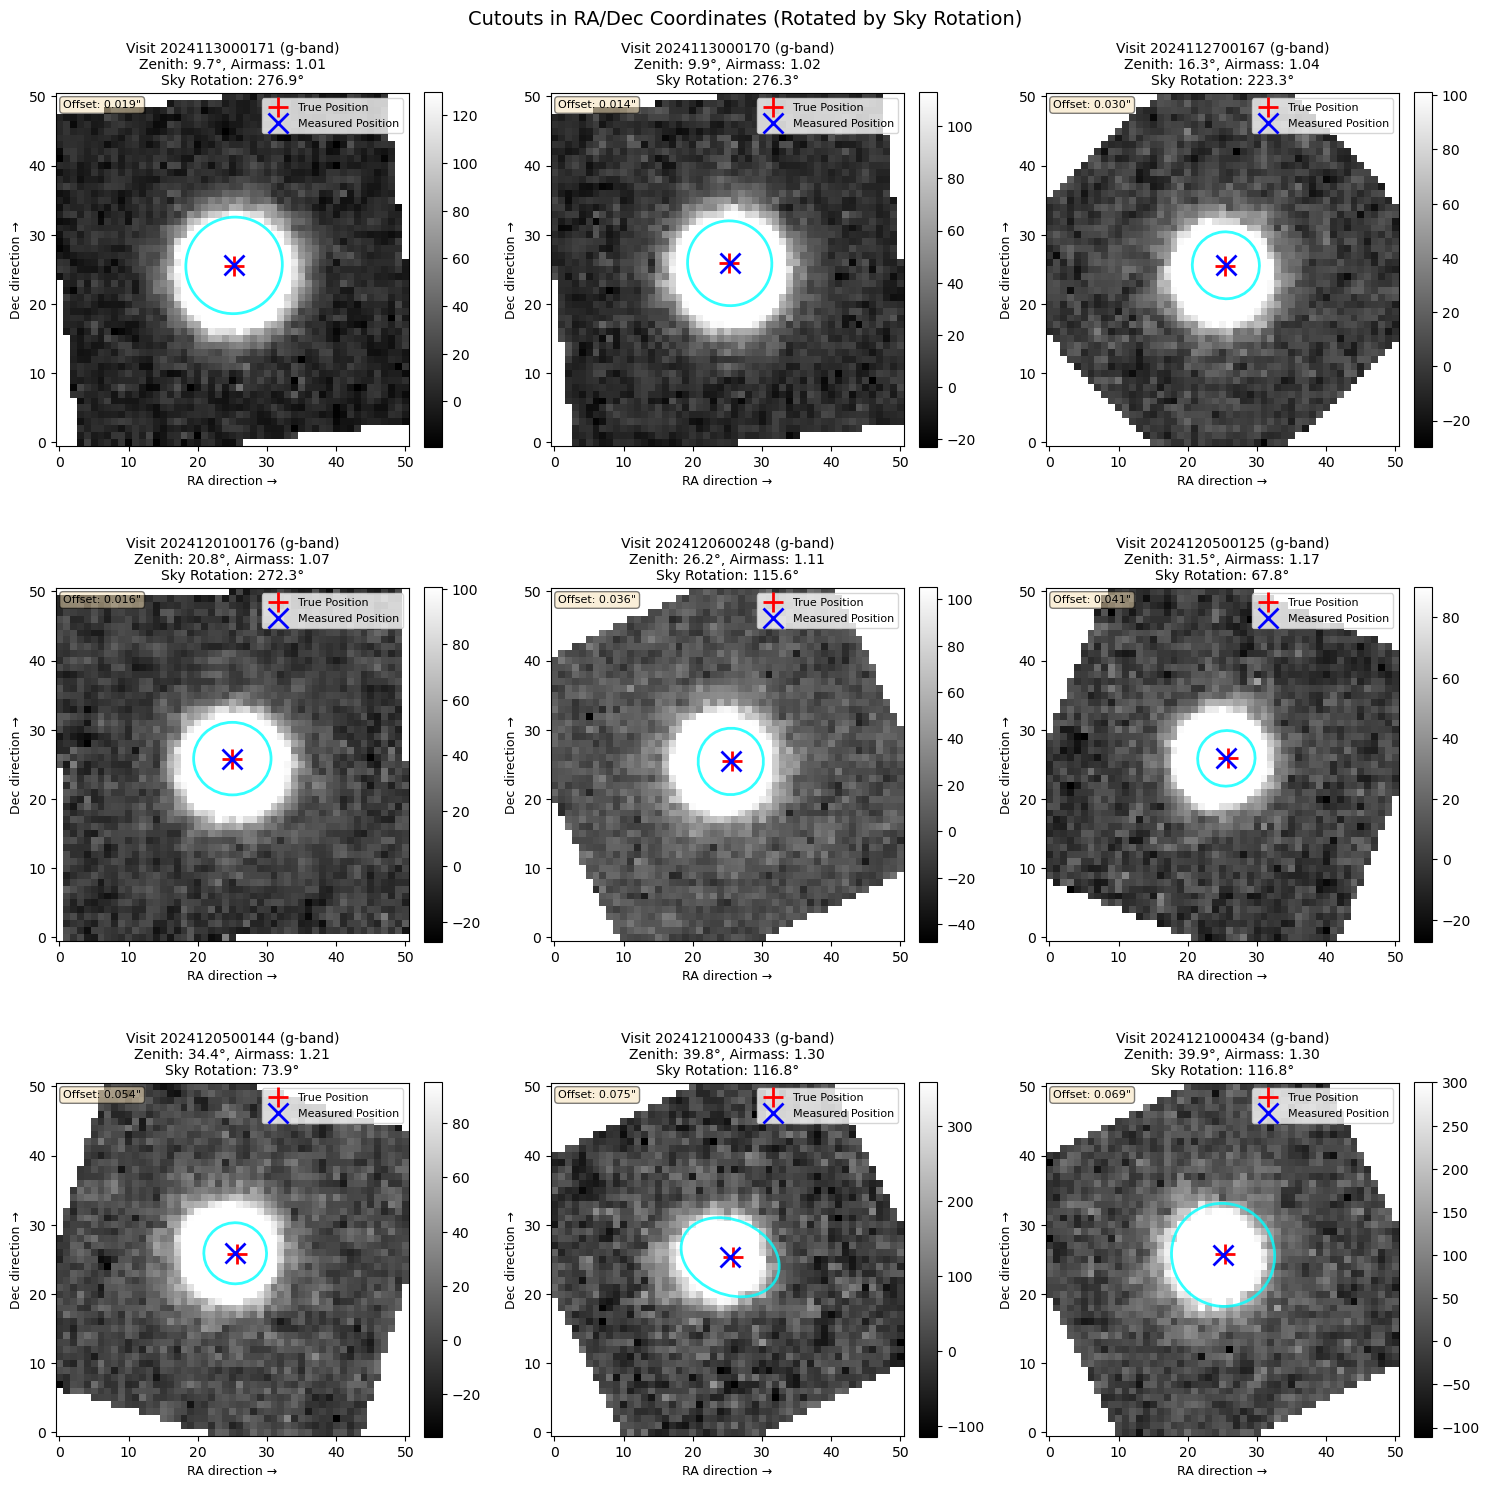

In [ ]:
# Plot cutouts in RA/Dec coordinates
def plot_cutouts_radec(selected_sources, cutouts, wcs_list, object_info, show_ellipses=True, arcsec_units=False, pixel_scale=0.2):
    """
    Plot cutouts in RA/Dec coordinates with true position marked
    
    Parameters:
    -----------
    selected_sources : DataFrame
        Source detections with observing conditions and shape measurements
    cutouts : list
        List of image cutouts
    wcs_list : list
        List of WCS objects for each cutout
    object_info : DataFrame
        Object information including true coordinates
    show_ellipses : bool
        If True, plot ellipses representing measured object shapes
    arcsec_units : bool
        If True, display coordinates in arcseconds relative to center
    pixel_scale : float
        Pixel scale in arcsec per pixel (default: 0.2)
    """
    from scipy.ndimage import rotate
    
    n_cutouts = len(cutouts)
    n_cols = 3
    n_rows = int(np.ceil(n_cutouts / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    true_ra = object_info['coord_ra'].values[0]
    true_dec = object_info['coord_dec'].values[0]
    
    for i, (idx, row) in enumerate(selected_sources.iterrows()):
        ax = axes.flatten()[i]
        
        if cutouts[i] is not None:
            image_data = cutouts[i].image.array
            
            # Rotate image by skyRotation angle to align with RA/Dec coordinates
            # skyRotation is the angle between camera coordinates and sky coordinates
            if 'skyRotation' in row.index and not pd.isna(row['skyRotation']):
                sky_rotation = row['skyRotation'] #already in degrees # np.degrees(row['skyRotation'])  # Convert from radians to degrees if needed
                rotated_image = rotate(image_data,360 -  sky_rotation , reshape=False, 
                                      order=1, mode='constant', cval=np.nan) #Why do you need the 180 - sky_rotation? I'm not sure
            else:
                # Fall back to original image if skyRotation not available
                rotated_image = image_data
                sky_rotation = 0.0
                print(f"Warning: skyRotation not available for visit {row['visit']}, using unrotated image")
            
            # Normalize image (excluding NaN values from rotation if any)
            if sky_rotation != 0.0:
                valid_data = rotated_image[~np.isnan(rotated_image)]
                if len(valid_data) > 0:
                    norm = ImageNormalize(valid_data, interval=ZScaleInterval())
                else:
                    norm = ImageNormalize(image_data, interval=ZScaleInterval())
            else:
                norm = ImageNormalize(rotated_image, interval=ZScaleInterval())
            
            # Set up coordinate system
            if arcsec_units:
                # Create extent in arcseconds relative to center
                ny, nx = rotated_image.shape
                extent_x = (np.arange(nx) - nx/2) * pixel_scale
                extent_y = (np.arange(ny) - ny/2) * pixel_scale
                extent = [extent_x[0], extent_x[-1], extent_y[0], extent_y[-1]]
                coord_transform = lambda x, y: ((x - nx/2) * pixel_scale, (y - ny/2) * pixel_scale)
                coord_units = "arcsec"
            else:
                extent = None
                coord_transform = lambda x, y: (x, y)
                coord_units = "pixels"
            
            # Plot rotated image
            im = ax.imshow(rotated_image, origin='lower', norm=norm, cmap='gray', extent=extent)
            
            # Mark the true and measured positions (rotated to RA/Dec frame)
            if wcs_list[i] is not None:
                from lsst.geom import SpherePoint, degrees
                true_point = SpherePoint(true_ra*degrees, true_dec*degrees)
                pixel_pos = wcs_list[i].skyToPixel(true_point)
                
                # Adjust for cutout offset
                bbox = cutouts[i].getBBox()
                x_true_cam = pixel_pos.getX() - bbox.getMinX()
                y_true_cam = pixel_pos.getY() - bbox.getMinY()
                
                # Mark measured position in camera coordinates
                meas_point = SpherePoint(row['coord_ra']*degrees, 
                                        row['coord_dec']*degrees)
                meas_pixel = wcs_list[i].skyToPixel(meas_point)
                x_meas_cam = meas_pixel.getX() - bbox.getMinX()
                y_meas_cam = meas_pixel.getY() - bbox.getMinY()
                
                # Rotate positions to RA/Dec frame
                if sky_rotation != 0.0:
                    # Center of rotation
                    cy, cx = image_data.shape[0] / 2, image_data.shape[1] / 2
                    
                    # Rotate true position
                    dx_true = x_true_cam - cx
                    dy_true = y_true_cam - cy
                    angle_rad = np.radians(sky_rotation)
                    cos_a = np.cos(angle_rad)
                    sin_a = np.sin(angle_rad)
                    
                    dx_true_rot = dx_true * cos_a - dy_true * sin_a
                    dy_true_rot = dx_true * sin_a + dy_true * cos_a
                    x_true_sky = cx + dx_true_rot
                    y_true_sky = cy + dy_true_rot
                    
                    # Rotate measured position
                    dx_meas = x_meas_cam - cx
                    dy_meas = y_meas_cam - cy
                    
                    dx_meas_rot = dx_meas * cos_a - dy_meas * sin_a
                    dy_meas_rot = dx_meas * sin_a + dy_meas * cos_a
                    x_meas_sky = cx + dx_meas_rot
                    y_meas_sky = cy + dy_meas_rot
                else:
                    x_true_sky, y_true_sky = x_true_cam, y_true_cam
                    x_meas_sky, y_meas_sky = x_meas_cam, y_meas_cam
                
                # Convert to display coordinates
                x_true_disp, y_true_disp = coord_transform(x_true_sky, y_true_sky)
                x_meas_disp, y_meas_disp = coord_transform(x_meas_sky, y_meas_sky)
                
                ax.plot(x_true_disp, y_true_disp, 'r+', markersize=15, 
                       markeredgewidth=2, label='True Position')
                ax.plot(x_meas_disp, y_meas_disp, 'bx', markersize=15, 
                       markeredgewidth=2, label='Measured Position')
                
                # Calculate offset in arcsec
                offset_pix = np.sqrt((x_true_sky - x_meas_sky)**2 + (y_true_sky - y_meas_sky)**2)
                offset_arcsec = offset_pix * pixel_scale
                
                ax.legend(fontsize=8, loc='upper right')
                ax.text(0.02, 0.98, f'Offset: {offset_arcsec:.3f}"', 
                       transform=ax.transAxes, fontsize=8, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                # Plot ellipse representing measured object shape (rotated to RA/Dec frame)
                if show_ellipses and all(col in row.index for col in ['ixx', 'iyy', 'ixy']):
                    # Convert second moments to ellipse parameters
                    ixx, iyy, ixy = row['ixx'], row['iyy'], row['ixy']
                    
                    # Calculate ellipse parameters from second moments
                    trace = ixx + iyy
                    det = ixx * iyy - ixy**2
                    
                    if det > 0 and trace > 0:  # Valid ellipse
                        # Semi-major and semi-minor axes (in pixels)
                        sqrt_term = np.sqrt((ixx - iyy)**2 + 4*ixy**2)
                        a = np.sqrt(0.5 * (trace + sqrt_term))  # semi-major axis
                        b = np.sqrt(0.5 * (trace - sqrt_term))  # semi-minor axis
                        
                        # Orientation angle in camera coordinates (in degrees)
                        theta_cam = 0.5 * np.degrees(np.arctan2(2*ixy, ixx - iyy))
                        
                        # Rotate ellipse angle to RA/Dec frame
                        theta_sky = theta_cam + sky_rotation
                        
                        # Convert ellipse dimensions to display units
                        if arcsec_units:
                            ellipse_width = 4 * a * pixel_scale
                            ellipse_height = 4 * b * pixel_scale
                        else:
                            ellipse_width = 4 * a
                            ellipse_height = 4 * b
                        
                        # Create ellipse patch (scaled by 2 to show ~2-sigma extent)
                        ellipse = Ellipse((x_meas_disp, y_meas_disp), width=ellipse_width, height=ellipse_height, 
                                        angle=theta_sky, fill=False, color='cyan', 
                                        linewidth=2, alpha=0.8, label='Measured Shape')
                        ax.add_patch(ellipse)
            
            ax.set_title(f"Visit {row['visit']} ({row['band']}-band)\n"
                        f"Zenith: {row['zenithDistance']:.1f}°, "
                        f"Airmass: {row['airmass']:.2f}\n"
                        f"Sky Rotation: {sky_rotation:.1f}°", fontsize=10)
            if arcsec_units:
                ax.set_xlabel('RA direction → (arcsec)', fontsize=9)
                ax.set_ylabel('Dec direction → (arcsec)', fontsize=9)
            else:
                ax.set_xlabel('RA direction → (pixels)', fontsize=9)
                ax.set_ylabel('Dec direction → (pixels)', fontsize=9)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
    
    # Hide extra subplots
    for i in range(n_cutouts, len(axes.flatten())):
        axes.flatten()[i].axis('off')
    
    plt.tight_layout()
    unit_str = " (arcsec units)" if arcsec_units else ""
    plt.suptitle(f'Cutouts in RA/Dec Coordinates (Rotated by Sky Rotation){unit_str}', fontsize=14, y=1.00)
    plt.show()

plot_cutouts_radec(selected_sources, cutouts, wcs_list, object_info, show_ellipses=True, arcsec_units=True)

### Important Note on Coordinate Systems

The original plotting function was incorrectly treating camera coordinates as sky coordinates. The updated `plot_cutouts_radec` function now properly:

1. **Rotates images** by the `skyRotation` angle to align camera coordinates with RA/Dec
2. **Transforms positions** (both true and measured) from camera frame to sky frame
3. **Rotates ellipse orientations** to match the sky coordinate system

This ensures that:
- **RA direction** is properly oriented (East ← West)  
- **Dec direction** is properly oriented (North ↑ South)
- **DCR effects** are correctly aligned with atmospheric refraction directions
- **Shape measurements** reflect actual sky orientations, not camera orientations

Without this correction, DCR analysis would be compromised because atmospheric effects occur in sky coordinates, not camera coordinates.

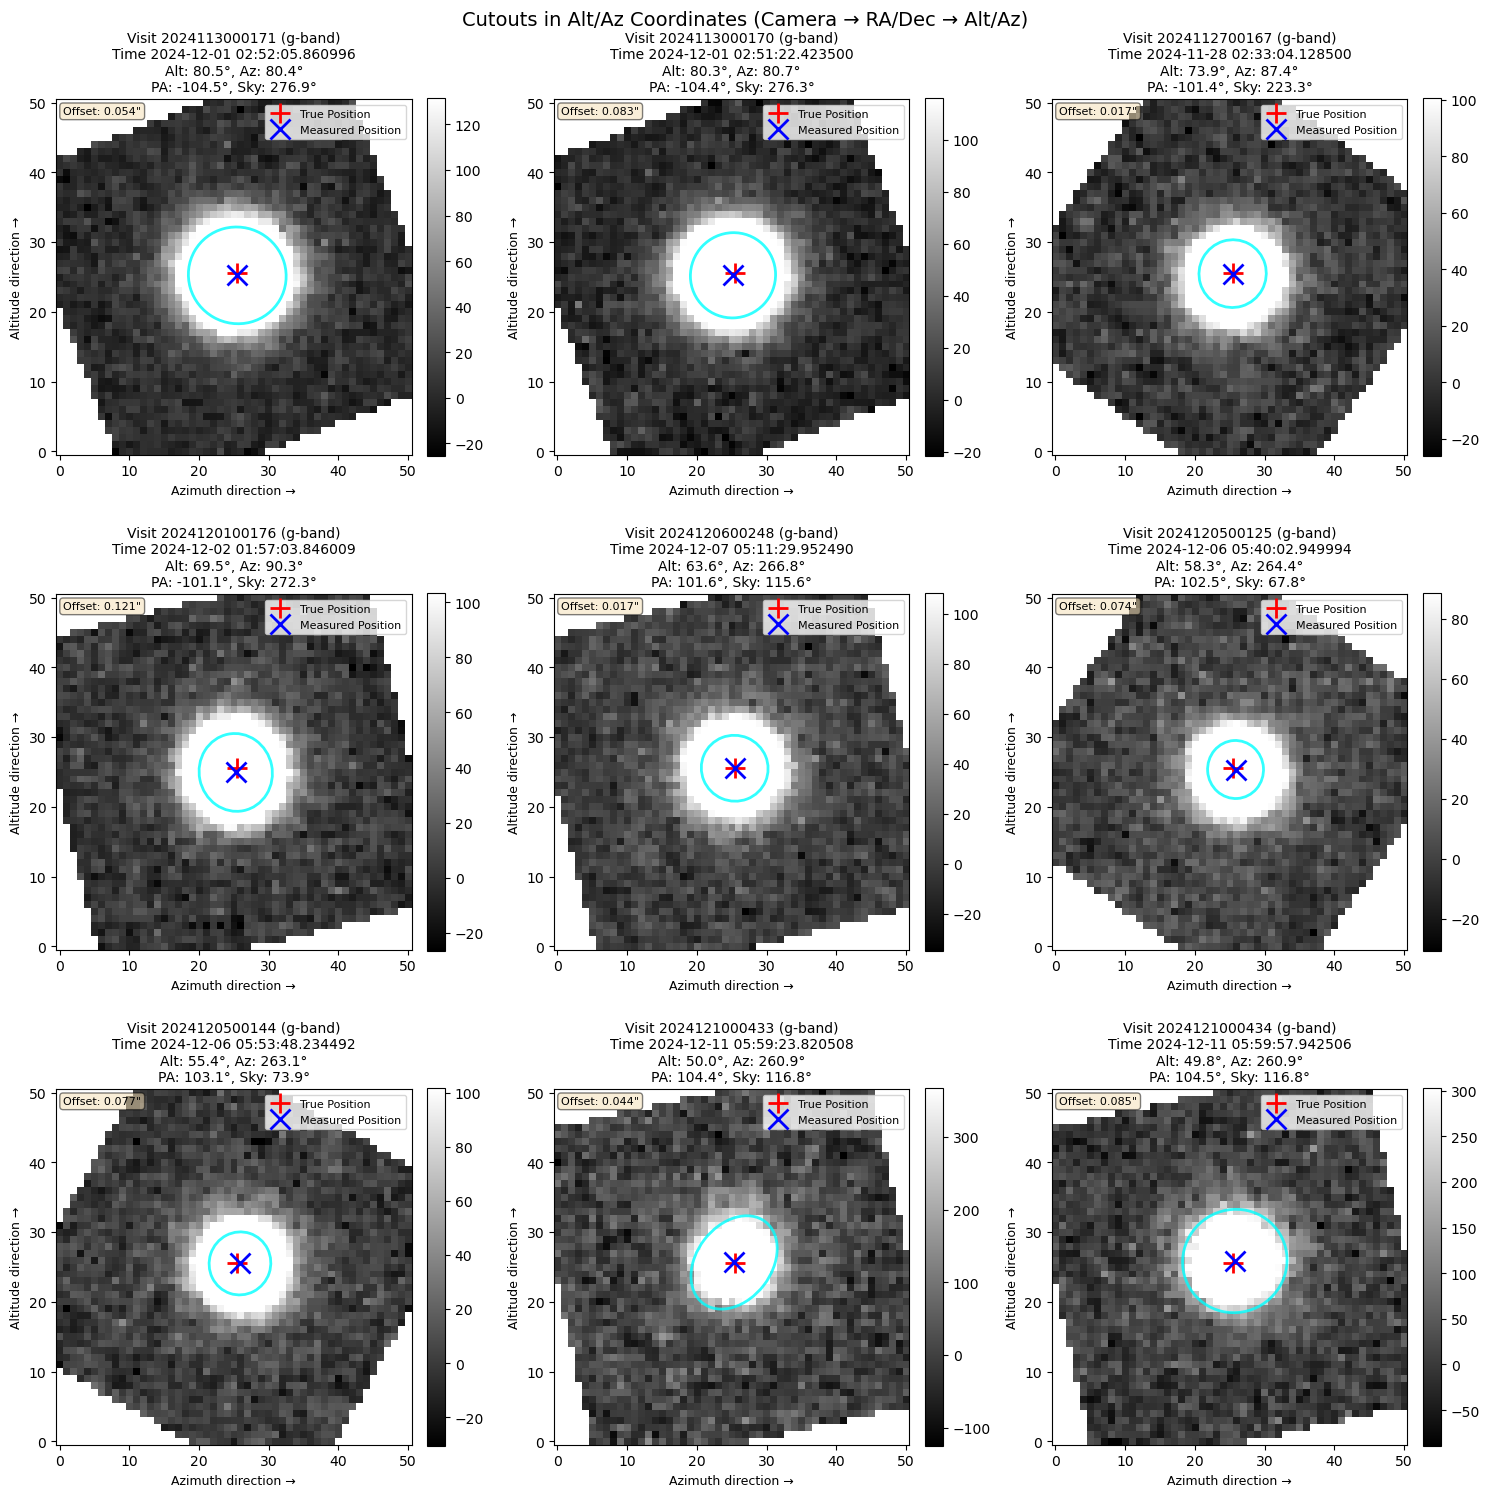

In [ ]:
# Plot cutouts in Alt/Az coordinates
from astropy.time import Time
def plot_cutouts_altaz(selected_sources, cutouts, wcs_list, object_info, show_ellipses=True, arcsec_units=False, pixel_scale=0.2):
    """
    Plot cutouts rotated to Alt/Az coordinates
    
    Parameters:
    -----------
    selected_sources : DataFrame
        Source detections with observing conditions and shape measurements
    cutouts : list
        List of image cutouts
    wcs_list : list
        List of WCS objects for each cutout
    object_info : DataFrame
        Object information including true coordinates
    show_ellipses : bool
        If True, plot ellipses representing measured object shapes
    arcsec_units : bool
        If True, display coordinates in arcseconds relative to center
    pixel_scale : float
        Pixel scale in arcsec per pixel (default: 0.2)
    """
    from scipy.ndimage import rotate
    
    n_cutouts = len(cutouts)
    n_cols = 3
    n_rows = int(np.ceil(n_cutouts / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    true_ra = object_info['coord_ra'].values[0]
    true_dec = object_info['coord_dec'].values[0]
    
    for i, (idx, row) in enumerate(selected_sources.iterrows()):
        ax = axes.flatten()[i]
        
        if cutouts[i] is not None:
            image_data = cutouts[i].image.array
            
            # Apply complete coordinate transformation: Camera -> RA/Dec -> Alt/Az
            # Step 1: Get skyRotation (Camera -> RA/Dec) 
            if 'skyRotation' in row.index and not pd.isna(row['skyRotation']):
                sky_rotation = row['skyRotation'] #np.degrees(row['skyRotation'])
            else:
                sky_rotation = 0.0
                print(f"Warning: skyRotation not available for visit {row['visit']}, using 0°")
            
            # Step 2: Get parallactic angle (RA/Dec -> Alt/Az)
            parallactic_angle = row['parallacticAngle']  # degrees
            
            # Total rotation from camera coordinates to Alt/Az coordinates
            total_rotation =  sky_rotation - parallactic_angle#sky_rotation + parallactic_angle
            
            rotated_image = rotate(image_data, 360 - sky_rotation + parallactic_angle, reshape=False, 
                                  order=1, mode='constant', cval=np.nan)
            
            # Normalize image (excluding NaN values from rotation)
            valid_data = rotated_image[~np.isnan(rotated_image)]
            if len(valid_data) > 0:
                norm = ImageNormalize(valid_data, interval=ZScaleInterval())
            else:
                norm = None
            
            # Set up coordinate system
            if arcsec_units:
                # Create extent in arcseconds relative to center
                ny, nx = rotated_image.shape
                extent_x = (np.arange(nx) - nx/2) * pixel_scale
                extent_y = (np.arange(ny) - ny/2) * pixel_scale
                extent = [extent_x[0], extent_x[-1], extent_y[0], extent_y[-1]]
                coord_transform = lambda x, y: ((x - nx/2) * pixel_scale, (y - ny/2) * pixel_scale)
                center_disp = (0, 0)  # Center is at origin in arcsec coordinates
            else:
                extent = None
                coord_transform = lambda x, y: (x, y)
                center_y, center_x = np.array(rotated_image.shape) / 2
                center_disp = (center_x, center_y)
            
            im = ax.imshow(rotated_image, origin='lower', norm=norm, cmap='gray', extent=extent)
            
            # Mark center (true position after rotation)
            ax.plot(center_disp[0], center_disp[1], 'r+', markersize=15, 
                   markeredgewidth=2, label='True Position')
            
            # Calculate and mark measured position after rotation
            if wcs_list[i] is not None:
                from lsst.geom import SpherePoint, degrees
                
                # Get pixel positions before rotation
                true_point = SpherePoint(true_ra*degrees, true_dec*degrees)
                meas_point = SpherePoint(row['coord_ra']*degrees, 
                                        row['coord_dec']*degrees)
                
                bbox = cutouts[i].getBBox()
                true_pix = wcs_list[i].skyToPixel(true_point)
                meas_pix = wcs_list[i].skyToPixel(meas_point)
                
                # Positions relative to cutout
                x_true = true_pix.getX() - bbox.getMinX()
                y_true = true_pix.getY() - bbox.getMinY()
                x_meas = meas_pix.getX() - bbox.getMinX()
                y_meas = meas_pix.getY() - bbox.getMinY()
                
                # Rotate the measured position coordinates by total rotation
                # Center of rotation
                cy, cx = image_data.shape[0] / 2, image_data.shape[1] / 2
                
                # Vector from center to measured position
                dx = x_meas - cx
                dy = y_meas - cy
                
                # Rotate by total angle (skyRotation + parallacticAngle)
                angle_rad = np.radians(total_rotation)
                cos_a = np.cos(angle_rad)
                sin_a = np.sin(angle_rad)
                
                dx_rot = dx * cos_a - dy * sin_a
                dy_rot = dx * sin_a + dy * cos_a
                
                x_meas_rot = cx + dx_rot
                y_meas_rot = cy + dy_rot
                
                # Convert to display coordinates
                x_meas_disp, y_meas_disp = coord_transform(x_meas_rot, y_meas_rot)
                
                ax.plot(x_meas_disp, y_meas_disp, 'bx', markersize=15, 
                       markeredgewidth=2, label='Measured Position')
                
                # Calculate offset
                if arcsec_units:
                    center_pix_x, center_pix_y = rotated_image.shape[1]/2, rotated_image.shape[0]/2
                    offset_pix = np.sqrt((center_pix_x - x_meas_rot)**2 + 
                                       (center_pix_y - y_meas_rot)**2)
                else:
                    offset_pix = np.sqrt((center_disp[0] - x_meas_rot)**2 + 
                                       (center_disp[1] - y_meas_rot)**2)
                offset_arcsec = offset_pix * pixel_scale
                
                ax.legend(fontsize=8, loc='upper right')
                ax.text(0.02, 0.98, f'Offset: {offset_arcsec:.3f}"', 
                       transform=ax.transAxes, fontsize=8, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                # Plot ellipse representing measured object shape (rotated)
                if show_ellipses and all(col in row.index for col in ['ixx', 'iyy', 'ixy']):
                    # Convert second moments to ellipse parameters
                    ixx, iyy, ixy = row['ixx'], row['iyy'], row['ixy']
                    
                    # Calculate ellipse parameters from second moments
                    trace = ixx + iyy
                    det = ixx * iyy - ixy**2
                    
                    if det > 0 and trace > 0:  # Valid ellipse
                        # Semi-major and semi-minor axes (in pixels)
                        sqrt_term = np.sqrt((ixx - iyy)**2 + 4*ixy**2)
                        a = np.sqrt(0.5 * (trace + sqrt_term))
                        b = np.sqrt(0.5 * (trace - sqrt_term))
                        
                        # Original orientation angle in camera coordinates
                        theta_cam = 0.5 * np.degrees(np.arctan2(2*ixy, ixx - iyy))
                        
                        # Rotate the ellipse angle by total rotation to Alt/Az frame
                        theta_altaz = theta_cam + sky_rotation - parallactic_angle
                        
                        # Convert ellipse dimensions to display units
                        if arcsec_units:
                            ellipse_width = 4 * a * pixel_scale
                            ellipse_height = 4 * b * pixel_scale
                        else:
                            ellipse_width = 4 * a
                            ellipse_height = 4 * b
                        
                        # Create ellipse patch (scaled by 2 to show ~2-sigma extent)
                        ellipse = Ellipse((x_meas_disp, y_meas_disp), width=ellipse_width, height=ellipse_height, 
                                        angle=theta_altaz, fill=False, color='cyan', 
                                        linewidth=2, alpha=0.8, label='Measured Shape')
                        ax.add_patch(ellipse)
            
            ax.set_title(f"Visit {row['visit']} ({row['band']}-band)\n"
                         f"Time {Time(row['expMidptMJD'], format='mjd', scale='utc').to_datetime()}\n"
                        f"Alt: {row['altitude']:.1f}°, Az: {row['azimuth']:.1f}°\n"
                        f"PA: {parallactic_angle:.1f}°, Sky: {sky_rotation:.1f}°", 
                        fontsize=10)
            if arcsec_units:
                ax.set_xlabel('Azimuth direction → (arcsec)', fontsize=9)
                ax.set_ylabel('Altitude direction → (arcsec)', fontsize=9)
            else:
                ax.set_xlabel('Azimuth direction → (pixels)', fontsize=9)
                ax.set_ylabel('Altitude direction → (pixels)', fontsize=9)
            
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
    
    # Hide extra subplots
    for i in range(n_cutouts, len(axes.flatten())):
        axes.flatten()[i].axis('off')
    
    plt.tight_layout()
    unit_str = " (arcsec units)" if arcsec_units else ""
    plt.suptitle(f'Cutouts in Alt/Az Coordinates (Camera → RA/Dec → Alt/Az){unit_str}', 
                 fontsize=14, y=1.00)
    plt.show()

plot_cutouts_altaz(selected_sources, cutouts, wcs_list, object_info, show_ellipses=True, arcsec_units=True)

### Alt/Az Coordinate Transformation

The `plot_cutouts_altaz` function now applies the **complete coordinate transformation chain**:

1. **Camera coordinates** (detector x/y pixels) 
   ↓ *rotate by `skyRotation`*
2. **RA/Dec coordinates** (celestial coordinates)
   ↓ *rotate by `parallacticAngle`*  
3. **Alt/Az coordinates** (horizon coordinates)

**Total rotation** = `skyRotation + parallacticAngle`

This ensures that:
- **Altitude direction** points toward zenith (where DCR effects are strongest)
- **Azimuth direction** is properly oriented around the horizon
- **DCR signatures** align with expected atmospheric refraction patterns
- **Object shapes and positions** reflect true orientations relative to the local horizon

The Alt/Az coordinate system is crucial for DCR analysis because differential chromatic refraction occurs **along the altitude direction** (toward/away from zenith) due to atmospheric density gradients.

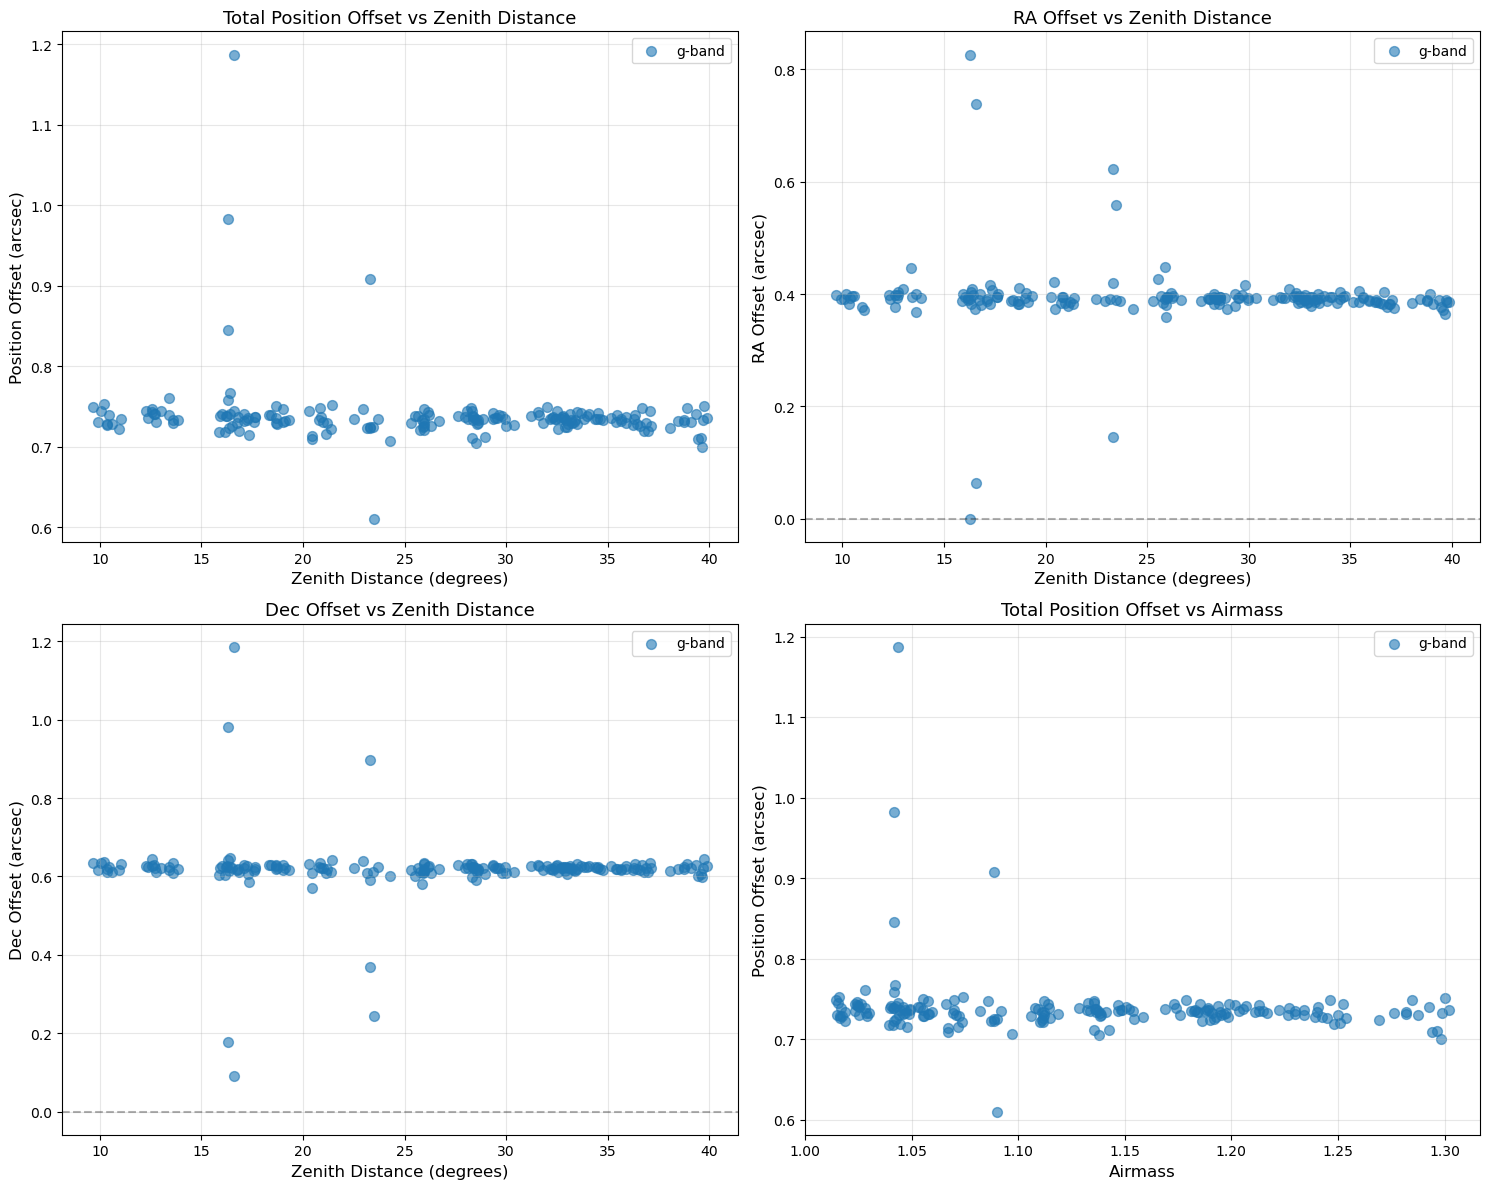

In [262]:
# Additional DCR diagnostic plots

# Plot 1: Position offset vs Zenith Distance
def plot_position_offset_vs_zenith(sources, object_info, bands = None):
    """
    Plot the measured position offset from true position vs zenith distance
    """
    true_ra = object_info['coord_ra'].values[0]
    true_dec = object_info['coord_dec'].values[0]
    
    # Calculate offsets for all sources
    offsets_ra = (sources['coord_ra'] - true_ra) * 3600 * np.cos(np.radians(true_dec))
    offsets_dec = (sources['coord_dec'] - true_dec) * 3600
    total_offset = np.sqrt(offsets_ra**2 + offsets_dec**2)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    if bands == None:
        bands = sources['band'].unique()
    
    # Plot 1: Total offset vs zenith distance
    ax = axes[0, 0]
    for band in bands:
        mask = sources['band'] == band
        ax.scatter(sources.loc[mask, 'zenithDistance'], 
                  total_offset[mask], 
                  label=f'{band}-band', alpha=0.6, s=50)
    ax.set_xlabel('Zenith Distance (degrees)', fontsize=12)
    ax.set_ylabel('Position Offset (arcsec)', fontsize=12)
    ax.set_title('Total Position Offset vs Zenith Distance', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: RA offset vs zenith distance
    ax = axes[0, 1]
    for band in bands:
        mask = sources['band'] == band
        ax.scatter(sources.loc[mask, 'zenithDistance'], 
                  offsets_ra[mask], 
                  label=f'{band}-band', alpha=0.6, s=50)
    ax.set_xlabel('Zenith Distance (degrees)', fontsize=12)
    ax.set_ylabel('RA Offset (arcsec)', fontsize=12)
    ax.set_title('RA Offset vs Zenith Distance', fontsize=13)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Dec offset vs zenith distance
    ax = axes[1, 0]
    for band in bands:
        mask = sources['band'] == band
        ax.scatter(sources.loc[mask, 'zenithDistance'], 
                  offsets_dec[mask], 
                  label=f'{band}-band', alpha=0.6, s=50)
    ax.set_xlabel('Zenith Distance (degrees)', fontsize=12)
    ax.set_ylabel('Dec Offset (arcsec)', fontsize=12)
    ax.set_title('Dec Offset vs Zenith Distance', fontsize=13)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Offset vs airmass
    ax = axes[1, 1]
    for band in bands:
        mask = sources['band'] == band
        ax.scatter(sources.loc[mask, 'airmass'], 
                  total_offset[mask], 
                  label=f'{band}-band', alpha=0.6, s=50)
    ax.set_xlabel('Airmass', fontsize=12)
    ax.set_ylabel('Position Offset (arcsec)', fontsize=12)
    ax.set_title('Total Position Offset vs Airmass', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_position_offset_vs_zenith(sources, object_info, bands = 'g')

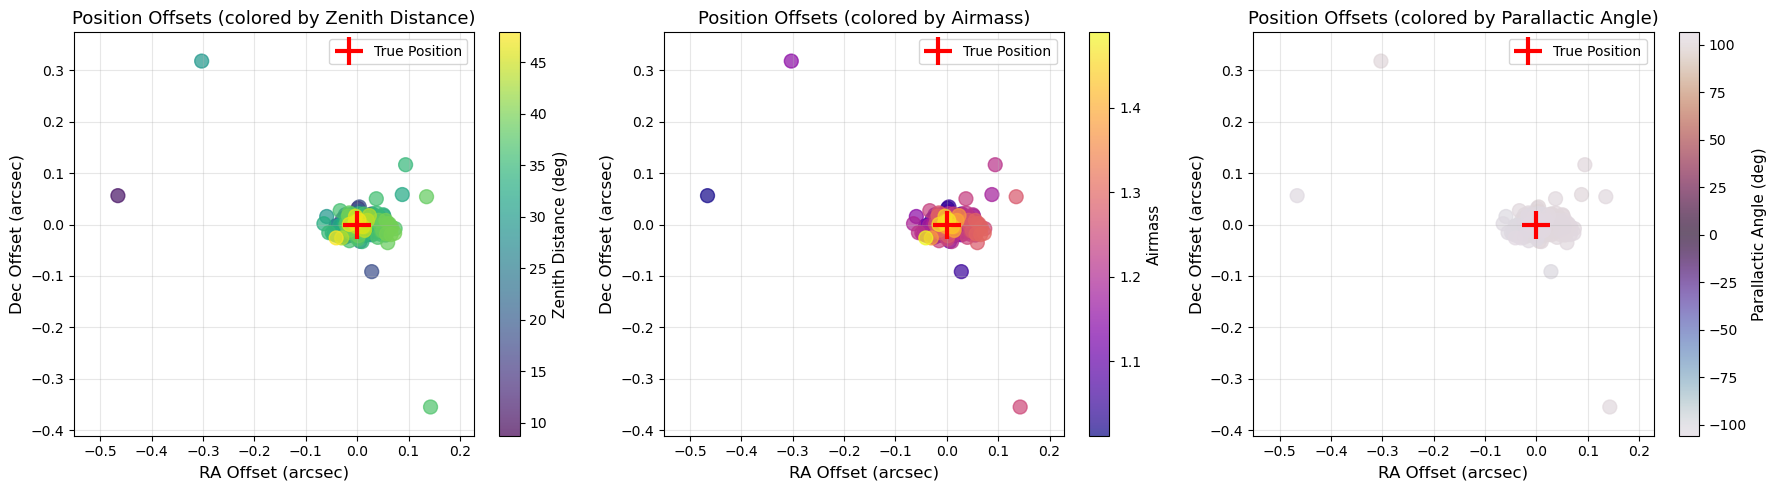

In [45]:
# Plot 2: Position offsets in RA/Dec plane colored by zenith angle
def plot_position_offsets_2d(sources, object_info):
    """
    Plot position offsets in the RA/Dec plane, colored by observing conditions
    """
    true_ra = object_info['coord_ra'].values[0]
    true_dec = object_info['coord_dec'].values[0]
    
    offsets_ra = (sources['coord_ra'] - true_ra) * 3600 * np.cos(np.radians(true_dec))
    offsets_dec = (sources['coord_dec'] - true_dec) * 3600
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Colored by zenith distance
    ax = axes[0]
    scatter = ax.scatter(offsets_ra, offsets_dec, 
                        c=sources['zenithDistance'], 
                        s=100, cmap='viridis', alpha=0.7)
    ax.plot(0, 0, 'r+', markersize=20, markeredgewidth=3, label='True Position')
    ax.set_xlabel('RA Offset (arcsec)', fontsize=12)
    ax.set_ylabel('Dec Offset (arcsec)', fontsize=12)
    ax.set_title('Position Offsets (colored by Zenith Distance)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.legend()
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Zenith Distance (deg)', fontsize=11)
    
    # Plot 2: Colored by airmass
    ax = axes[1]
    scatter = ax.scatter(offsets_ra, offsets_dec, 
                        c=sources['airmass'], 
                        s=100, cmap='plasma', alpha=0.7)
    ax.plot(0, 0, 'r+', markersize=20, markeredgewidth=3, label='True Position')
    ax.set_xlabel('RA Offset (arcsec)', fontsize=12)
    ax.set_ylabel('Dec Offset (arcsec)', fontsize=12)
    ax.set_title('Position Offsets (colored by Airmass)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.legend()
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Airmass', fontsize=11)
    
    # Plot 3: Colored by parallactic angle
    ax = axes[2]
    scatter = ax.scatter(offsets_ra, offsets_dec, 
                        c=sources['parallacticAngle'], 
                        s=100, cmap='twilight', alpha=0.7)
    ax.plot(0, 0, 'r+', markersize=20, markeredgewidth=3, label='True Position')
    ax.set_xlabel('RA Offset (arcsec)', fontsize=12)
    ax.set_ylabel('Dec Offset (arcsec)', fontsize=12)
    ax.set_title('Position Offsets (colored by Parallactic Angle)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    ax.legend()
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Parallactic Angle (deg)', fontsize=11)
    
    plt.tight_layout()
    plt.show()

plot_position_offsets_2d(sources, object_info)

In [48]:
# Plot 3: Offset direction vs parallactic angle (to see if DCR follows expected pattern)
def plot_offset_direction_analysis(sources, object_info):
    """
    Analyze the direction of position offsets
    DCR should cause offsets in the direction of zenith (altitude direction)
    """
    true_ra = object_info['coord_ra'].values[0]
    true_dec = object_info['coord_dec'].values[0]
    
    offsets_ra = (sources['coord_ra'] - true_ra) * 3600 * np.cos(np.radians(true_dec))
    offsets_dec = (sources['coord_dec'] - true_dec) * 3600
    
    # Calculate offset position angle (East of North)
    offset_pa = np.degrees(np.arctan2(offsets_ra, offsets_dec))
    
    # Calculate expected DCR direction (should be toward zenith)
    # The zenith direction in RA/Dec is perpendicular to the parallactic angle direction
    expected_dcr_pa = sources['parallacticAngle'] + 90
    
    # Normalize angles to -180 to 180
    offset_pa = (offset_pa + 180) % 360 - 180
    expected_dcr_pa = (expected_dcr_pa + 180) % 360 - 180
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Offset magnitude vs zenith distance by band
    ax = axes[0, 0]
    total_offset = np.sqrt(offsets_ra**2 + offsets_dec**2)
    for band in sources['band'].unique():
        mask = sources['band'] == band
        ax.scatter(sources.loc[mask, 'zenithDistance'], 
                  total_offset[mask], 
                  label=f'{band}-band', alpha=0.6, s=50)
    ax.set_xlabel('Zenith Distance (degrees)', fontsize=12)
    ax.set_